# Installing libaries

Installing the ChEMBL web service package to retrieve bioactivity data from the ChEMBL Database.

In [1]:
! pip install chembl_webresource_client

Defaulting to user installation because normal site-packages is not writeable

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importing Libraries

In [1]:
# Import necessary libraries
import pandas as pd
from chembl_webresource_client.new_client import new_client

# Search for Target Protein

## Target Protein for the project: LRRK2

LRRK2 (leucine-rich repeat kinase 2) is a genetically validated target strongly implicated in Parkinson’s disease (PD) pathogenesis. In 2025, it remains at the forefront of neurodegenerative drug discovery due to its key role in neuronal toxicity driven by overactive kinase activity, which contributes to dopamine neuron degeneration.

Recent scientific advances have shown that selective inhibition of LRRK2 can stabilize or slow disease progression, particularly if treatment starts early. Multiple next-generation LRRK2 kinase inhibitors are advancing through clinical trials with promising safety and efficacy profiles, underscoring its translational potential. Moreover, LRRK2's involvement extends to broader neurodegenerative and immune-related pathways, highlighting its wide biomedical relevance.

Choosing LRRK2 for QSAR modeling adds novelty by addressing a cutting-edge therapeutic challenge with unmet needs, supported by active global research and drug development efforts.

In [3]:
# Recommendation: Manually search chEMBL database and eplore relevant targets or search for a disease and find targets
# For this project, the target was chosen based on recent studies
target = new_client.target
target_query = target.search('LRRK2')
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Mus musculus,Leucine-rich repeat serine/threonine-protein k...,16.0,False,CHEMBL2010622,"[{'accession': 'Q5S006', 'component_descriptio...",SINGLE PROTEIN,10090
1,[],Homo sapiens,Leucine-rich repeat serine/threonine-protein k...,15.0,False,CHEMBL1075104,"[{'accession': 'Q5S007', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Mus musculus,Protein cereblon/Lrrk2,15.0,False,CHEMBL4802028,"[{'accession': 'Q5S006', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,10090
3,[],Homo sapiens,Protein cereblon/Leucine-rich repeat serine/th...,14.0,False,CHEMBL5465219,"[{'accession': 'Q5S007', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606
4,[],Mus musculus,von Hippel-Lindau disease tumor suppressor-LRRK2,13.0,False,CHEMBL5465252,"[{'accession': 'Q5S006', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,10090
5,[],Homo sapiens,von Hippel-Lindau disease tumor suppressor/Leu...,12.0,False,CHEMBL5465239,"[{'accession': 'Q5S007', 'component_descriptio...",PROTEIN-PROTEIN INTERACTION,9606


Before delving deeper, here's a quick breakdown of what each column in the ChEMBL target search results represents:

| Column Name         | Description                                                  |
|---------------------|--------------------------------------------------------------|
| cross_references    | Links to external databases (UniProt, etc.)                  |
| organism            | Species where the target is found                            |
| pref_name           | Standardized name of the target protein or entity            |
| score               | Relevance score from search query matching (higher is better)                   |
| species_group_flag  | Indicates if target exists across multiple species           |
| target_chembl_id    | Unique identifier for the biological target in ChEMBL        |
| target_components   | Detailed structural information about protein domains        |
| target_type         | Classification of target (single protein, complex, etc.)     |
| tax_id              | NCBI taxonomy identifier for the organism                    |

### 🧬 Target Selection

- **Organism: _Homo sapiens_ (human)**  
  For this project, Human targets are prioritized to ensure relevance for biomedical research and therapeutic applications.

- **Target Type: SINGLE PROTEIN**  
  Focusing on individual proteins allows for clearer interpretation of binding interactions and simplifies downstream analysis compared to complex protein assemblies.

## Select and retrieve bioactivity data for the selected target 

We will assign the second entry (which corresponds to the target protein in the chosen organism) to the selected_target variable.

In [4]:
selected_target = targets.target_chembl_id[1]
selected_target

'CHEMBL1075104'

Next, we will retrieve only bioactivity data for LRRK2 (CHEMBL1075104) that are reported as IC50 values in nM (nanomolar) unit.

What is IC50?

- IC50 stands for "Half Maximal Inhibitory Concentration".
- It is the concentration of a drug required to inhibit a biological target by 50% in a lab experiment.
- It is a measure of potency: the lower the IC50, the more potent the drug (because it takes less drug to achieve the effect).

Why is IC50 a standard?

- It is a reproducible and widely used metric in biochemistry and pharmacology.
- It allows for comparison between different compounds and different studies.

In [5]:
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

In [10]:
# Data type of the output variable
type(res)

chembl_webresource_client.query_set.QuerySet

In [11]:
# Converting to a pandas dataframe (Beware! This takes really long to run!)
df = pd.DataFrame.from_dict(res)

In [12]:
# Viewing the first few lines of the df
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,6180232,[],CHEMBL1772597,Inhibition of purified N-terminal GST-tagged L...,B,Q5S007,G2019S,BAO_0000190,...,Homo sapiens,Leucine-rich repeat serine/threonine-protein k...,9606,None,None,IC50,uM,UO_0000065,None,13.2
1,None,None,6180234,[],CHEMBL1772599,Inhibition of purified N-terminal GST-tagged L...,B,Q5S007,G2019S,BAO_0000190,...,Homo sapiens,Leucine-rich repeat serine/threonine-protein k...,9606,None,None,IC50,uM,UO_0000065,None,4.1
2,None,None,7989381,[],CHEMBL1937075,Inhibition of human LRRK2,B,None,None,BAO_0000190,...,Homo sapiens,Leucine-rich repeat serine/threonine-protein k...,9606,None,None,IC50,nM,UO_0000065,None,16.0
3,None,None,10840480,[],CHEMBL2015541,Inhibition of wild-type LRRK2 expressed in HEK...,B,None,None,BAO_0000190,...,Homo sapiens,Leucine-rich repeat serine/threonine-protein k...,9606,None,None,IC50,nM,UO_0000065,None,13.0
4,None,None,10840481,[],CHEMBL2015541,Inhibition of wild-type LRRK2 expressed in HEK...,B,None,None,BAO_0000190,...,Homo sapiens,Leucine-rich repeat serine/threonine-protein k...,9606,None,None,IC50,nM,UO_0000065,None,7.8


Save the resulting bioactivity data to a CSV file bioactivity_data.csv.

In [13]:
df.to_csv('../data/bioactivity_data.csv', index=False)

In [9]:
df = pd.read_csv("../data/bioactivity_data.csv")

In [10]:
# Exploring the activity data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6623 entries, 0 to 6622
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   action_type                875 non-null    object 
 1   activity_comment           4689 non-null   object 
 2   activity_id                6623 non-null   int64  
 3   activity_properties        6623 non-null   object 
 4   assay_chembl_id            6623 non-null   object 
 5   assay_description          6623 non-null   object 
 6   assay_type                 6623 non-null   object 
 7   assay_variant_accession    1012 non-null   object 
 8   assay_variant_mutation     1012 non-null   object 
 9   bao_endpoint               6623 non-null   object 
 10  bao_format                 6623 non-null   object 
 11  bao_label                  6623 non-null   object 
 12  canonical_smiles           6621 non-null   object 
 13  data_validity_comment      3 non-null      objec

In [11]:
df.describe()

,activity_id,document_year,pchembl_value,potential_duplicate,record_id,src_id,standard_flag,standard_text_value,standard_upper_value,standard_value,target_tax_id,text_value,toid,upper_value,value
count,6.623000e+03,6623.000000,4329.000000,6623.000000,6.623000e+03,6623.000000,6623.000000,0.0,0.0,6553.000000,6623.0,0.0,0.0,3.000000,6553.000000
mean,2.433900e+07,2019.211687,7.342705,0.122452,3.844665e+06,26.838291,0.989431,NaN,NaN,779.802457,9606.0,NaN,NaN,8.126667,392.336318
std,5.227041e+06,3.190215,1.016280,0.327832,8.413430e+05,16.944799,0.102270,NaN,NaN,5397.323169,0.0,NaN,NaN,9.000452,2731.316729
min,6.180232e+06,2009.000000,4.040000,0.000000,1.420091e+06,1.000000,0.000000,NaN,NaN,0.001000,9606.0,NaN,NaN,0.380000,0.001000
25%,1.814378e+07,2016.000000,6.590000,0.000000,3.009688e+06,1.000000,1.000000,NaN,NaN,17.000000,9606.0,NaN,NaN,3.190000,8.000000
50%,2.673596e+07,2021.000000,7.350000,0.000000,4.161261e+06,37.000000,1.000000,NaN,NaN,50.000000,9606.0,NaN,NaN,6.000000,30.000000
75%,2.858678e+07,2022.000000,8.100000,0.000000,4.547926e+06,37.000000,1.000000,NaN,NaN,151.000000,9606.0,NaN,NaN,12.000000,100.000000
max,2.895705e+07,2024.000000,10.190000,1.000000,4.626658e+06,72.000000,1.000000,NaN,NaN,101080.000000,9606.0,NaN,NaN,18.000000,101080.000000


Our column of interest is 'standard_value' that contains actual IC50 numerical value that quantifies compound potency. However, we observe that it stores values as 'object' datatype. This warrants some pre-processing before we can progress further.

# Handling missing data

In [7]:
df2 = df[df.standard_value.notna()]
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6553 entries, 0 to 6622
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   action_type                875 non-null    object 
 1   activity_comment           4619 non-null   object 
 2   activity_id                6553 non-null   int64  
 3   activity_properties        6553 non-null   object 
 4   assay_chembl_id            6553 non-null   object 
 5   assay_description          6553 non-null   object 
 6   assay_type                 6553 non-null   object 
 7   assay_variant_accession    994 non-null    object 
 8   assay_variant_mutation     994 non-null    object 
 9   bao_endpoint               6553 non-null   object 
 10  bao_format                 6553 non-null   object 
 11  bao_label                  6553 non-null   object 
 12  canonical_smiles           6551 non-null   object 
 13  data_validity_comment      3 non-null      objec

# Visualising the distribution of 'standard_value'

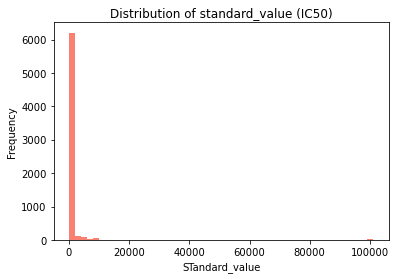

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.hist(df2['standard_value'], bins=50, color='salmon')
plt.title('Distribution of standard_value (IC50)')
plt.xlabel('Standard_value')
plt.ylabel('Frequency')
plt.show()

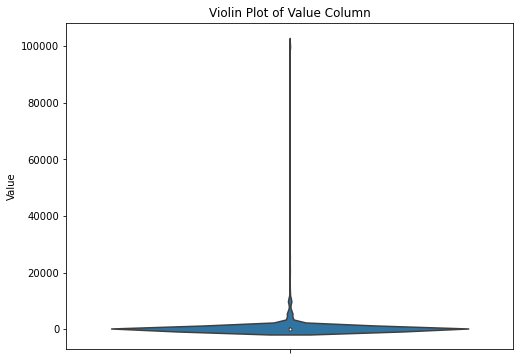

In [23]:
plt.figure(figsize=(8, 6)) # Optional: set figure size
sns.violinplot(y=df2['standard_value']) # Plotting the 'Value' column
plt.title('Violin Plot of IC50 Value Column')
plt.ylabel('Value')
plt.show()

# Data Preprocessing

##  IC50 Activity Labelling

Compounds are labeled as "active" (IC50 ≤ 1000 nM), "inactive" (IC50 ≥ 10000 nM), or "intermediate" based on standard potency cutoffs widely used in drug discovery. This keeps the classification clear and consistent across diverse targets, reflecting accepted community benchmarks for meaningful inhibitor strength.

In [21]:
import numpy as np

conditions = [
    df2['standard_value'] >= 10000,
    df2['standard_value'] <= 1000
]
choices = ['inactive', 'active']

df2['bioactivity_class'] = np.select(conditions, choices, default='intermediate')

In [22]:
# Saving the pre-processed data in another dataframe
df3 = df2[['molecule_chembl_id', 'canonical_smiles', 'standard_value','bioactivity_class']]
df3

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL1771409,Cc1cc(N/N=C/c2ccc(O)c(O)c2)nc2ccccc12,13200.00,inactive
1,CHEMBL1771411,Cc1cc(N/N=C/c2ccncc2)nc2ccccc12,4100.00,intermediate
2,CHEMBL1933288,C[C@@H]1CCNC(=O)c2cc3ccc(C(=O)Nc4nc5ccccc5n4CC...,16.00,active
3,CHEMBL2012582,COc1cc(C(=O)N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc2c...,13.00,active
4,CHEMBL509032,COc1cc(N2CCC(N3CCN(C)CC3)CC2)ccc1Nc1ncc(Cl)c(N...,7.80,active
...,...,...,...,...
6618,CHEMBL5753712,Cn1nc(C(C)(C)n2nccn2)cc1Nc1ncc(C(F)(F)F)c(NC2C...,2.23,active
6619,CHEMBL5838116,CCNc1nc(Nc2cc(C(C)(C)n3nccn3)nn2C2CC2)ncc1C(F)...,3.69,active
6620,CHEMBL5740646,CCNc1nc(Nc2cnn(C3CC(C#N)C3)c2C)ncc1C(F)(F)F,3.41,active
6621,CHEMBL5744573,CCNc1nc(Nc2cn(C(C)(C)C#N)nc2C2CC2)ncc1C(F)(F)F,1.55,active


In [23]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6553 entries, 0 to 6622
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  6553 non-null   object 
 1   canonical_smiles    6551 non-null   object 
 2   standard_value      6553 non-null   float64
 3   bioactivity_class   6553 non-null   object 
dtypes: float64(1), object(3)
memory usage: 514.0+ KB


In [24]:
df3.to_csv('../data/bioactivity_preprocessed_data.csv', index=False)